# NES-VMC K=3 Full Enumeration Diagnostic

这个 notebook 的目的：**不用 MetropolisSampler，不用 ExactSampler，直接枚举 H₂ / 6-31G 下 K=3 的所有合法 NES 构型**。

对于 H₂ / 6-31G：单系统 Hilbert 空间大小为 16。K=3 且要求子组态不重复时，合法 NES ordered samples 数量为：

\[
16\times 15\times 14=3360.
\]

这个 notebook 用这些 3360 个构型直接计算 exact NES loss / gradient / E_L matrix / 子空间 Ritz 诊断。这样可以先把 sampler 从嫌疑名单里踢出去，虽然它肯定会委屈，毕竟代码模块都觉得自己无辜。

In [1]:
import os
import sys
import time
import itertools
import numpy as np

import jax
import jax.numpy as jnp
import flax.nnx as nnx
import optax
import netket as nk
import netket.experimental as nkx

from jax.flatten_util import ravel_pytree
from pyscf import gto, scf, fci

jax.config.update("jax_enable_x64", True)

jnp.set_printoptions(
    linewidth=9999,
    threshold=jnp.inf,
    precision=8,
    suppress=False,
)

print("JAX devices:", jax.devices())

/opt/miniconda3/envs/Netket/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


∣NK⟩ Tip: You can load logged data with nk.utils.history.HistoryDict.from_file(data.log).

JAX devices: [CpuDevice(id=0)]


## 1. 系统设置：H₂ / 6-31G

默认键长设置为 `1.8`，如果你之前实验用的是 `1.4`，直接改下面的 `BOND_LENGTH`。

In [2]:
# ============================================================
# 1. Molecule / Hilbert / Hamiltonian
# ============================================================

BOND_LENGTH = 1.8
BASIS = "6-31G"
K = 3
HIDDEN_DIM = 12
RNG_SEED = 11

geometry = [
    ("H", (0.0, 0.0, 0.0)),
    ("H", (BOND_LENGTH, 0.0, 0.0)),
]

mol = gto.M(atom=geometry, basis=BASIS, verbose=0)
mf = scf.RHF(mol).run(verbose=0)
hf_ground_energy = mf.e_tot

cisolver = fci.FCI(mf)
cisolver.nroots = 4
E_fcis, fcivec = cisolver.kernel()

hi = nk.hilbert.SpinOrbitalFermions(
    n_orbitals=4,
    s=1/2,
    n_fermions_per_spin=(1, 1),
)

ha = nkx.operator.from_pyscf_molecule(mol)
H_dense = jnp.asarray(ha.to_dense(), dtype=jnp.complex128)

SINGLE_SIZE = hi.size
all_single_states = jnp.asarray(hi.all_states(), dtype=jnp.float64)
HF_ref = all_single_states[0]

target_loss = float(np.sum(np.asarray(E_fcis[:K])))

print("=" * 80)
print("H2 / 6-31G benchmark")
print("=" * 80)
print(f"bond_length = {BOND_LENGTH}")
print(f"HF energy   = {hf_ground_energy:.10f} Ha")
for i, e in enumerate(E_fcis):
    exc = (e - E_fcis[0]) * 27.2114
    print(f"FCI E{i} = {e:.10f} Ha | excitation = {exc:.6f} eV")
print("-" * 80)
print(f"K = {K}")
print(f"target sum E0..E{K-1} = {target_loss:.10f} Ha")
print(f"hi.size = {hi.size}")
print(f"single Hilbert size = {all_single_states.shape[0]}")
print("HF_ref =", HF_ref)
print("H_dense.shape =", H_dense.shape)
print("=" * 80)

H2 / 6-31G benchmark
bond_length = 1.8
HF energy   = -0.9460522014 Ha
FCI E0 = -1.0261357178 Ha | excitation = 0.000000 eV
FCI E1 = -0.9789220400 Ha | excitation = 1.284750 eV
FCI E2 = -0.6677615736 Ha | excitation = 9.751862 eV
FCI E3 = -0.6081704578 Ha | excitation = 11.373420 eV
--------------------------------------------------------------------------------
K = 3
target sum E0..E2 = -2.6728193313 Ha
hi.size = 8
single Hilbert size = 16
HF_ref = [0. 0. 0. 1. 0. 0. 0. 1.]
H_dense.shape = (16, 16)


## 2. 枚举所有合法 NES 构型

合法条件：

\[
X=(x_1,x_2,x_3),\quad x_i\neq x_j \quad (i\neq j).
\]

这里枚举的是 ordered tuple，所以 K=3 时共有 \(16P3=3360\) 个。

In [3]:
def build_valid_nes_configurations(hi, K, single_size, dtype=jnp.float64):
    """
    枚举所有合法 NES samples:
        X = [x_1, ..., x_K]
    要求:
        x_i != x_j  for i != j

    返回:
        valid_X: shape (N_valid, K, single_size)
        perm_indices: shape (N_valid, K)
        single_states: shape (N_single, single_size)
    """
    single_states = jnp.asarray(hi.all_states(), dtype=dtype)
    n_single = single_states.shape[0]

    perm_indices_np = np.asarray(
        list(itertools.permutations(range(n_single), K)),
        dtype=np.int32,
    )

    perm_indices = jnp.asarray(perm_indices_np)
    valid_X = single_states[perm_indices]

    expected = int(np.prod([n_single - i for i in range(K)]))

    assert valid_X.shape == (expected, K, single_size), (
        f"valid_X.shape={valid_X.shape}, expected {(expected, K, single_size)}"
    )

    return valid_X, perm_indices, single_states


valid_X, perm_indices, single_states = build_valid_nes_configurations(
    hi=hi,
    K=K,
    single_size=SINGLE_SIZE,
)

print("=" * 80)
print("NES full enumeration")
print("=" * 80)
print(f"single_states.shape = {single_states.shape}")
print(f"perm_indices.shape  = {perm_indices.shape}")
print(f"valid_X.shape       = {valid_X.shape}")
print("Expected valid count for K=3:", 16 * 15 * 14)
print("=" * 80)

NES full enumeration
single_states.shape = (16, 8)
perm_indices.shape  = (3360, 3)
valid_X.shape       = (3360, 3, 8)
Expected valid count for K=3: 3360


## 3. 自包含的 NNX 模型

这里给一个最小可运行的 complex FFNN 版本。第一轮诊断建议先不要加 Jastrow。Jastrow 很容易把 amplitude drift 放大，喜欢把训练变成抽象艺术展。

In [5]:
class SingleStateAnsatzEnum(nnx.Module):
    """
    单态 complex FFNN ansatz。

    输入:
        x: shape (..., n_spin)
    输出:
        logψ(x): shape (...,)
    """
    def __init__(self, n_spin_orbitals: int, hidden_dim: int = 12, *, rngs: nnx.Rngs):
        self.n_spin = n_spin_orbitals
        self.hidden_dim = hidden_dim

        self.lin1 = nnx.Linear(
            self.n_spin,
            hidden_dim,
            param_dtype=jnp.complex128,
            rngs=rngs,
        )
        self.lin2 = nnx.Linear(
            hidden_dim,
            hidden_dim,
            param_dtype=jnp.complex128,
            rngs=rngs,
        )
        self.lin3 = nnx.Linear(
            hidden_dim,
            hidden_dim,
            param_dtype=jnp.complex128,
            rngs=rngs,
        )
        self.lin_out = nnx.Linear(
            hidden_dim,
            1,
            param_dtype=jnp.complex128,
            rngs=rngs,
        )

    def __call__(self, x):
        x_c = x.astype(jnp.complex128)

        h = jnp.tanh(self.lin1(x_c))
        h = jnp.tanh(self.lin2(h))
        h = jnp.tanh(self.lin3(h))
        out = self.lin_out(h)

        return jnp.squeeze(out, axis=-1)


class NESTotalAnsatzEnum(nnx.Module):
    """
    K 个 SingleStateAnsatz 的容器。
    这里不直接在 __call__ 中构造 determinant；
    exact enumeration loss 会显式构造 K×K 矩阵。
    """
    def __init__(self, n_spin_orbitals: int, K: int, hidden_dim: int = 12, *, rngs: nnx.Rngs):
        self.n_spin = n_spin_orbitals
        self.K = K
        self.single_ansatz_list = nnx.List()
        for _ in range(K):
            self.single_ansatz_list.append(
                SingleStateAnsatzEnum(
                    n_spin_orbitals=n_spin_orbitals,
                    hidden_dim=hidden_dim,
                    rngs=rngs,
                )
            )


rngs = nnx.Rngs(RNG_SEED)
total_model = NESTotalAnsatzEnum(
    n_spin_orbitals=SINGLE_SIZE,
    K=K,
    hidden_dim=HIDDEN_DIM,
    rngs=rngs,
)

total_graphdef, total_params = nnx.split(total_model)

print("Model initialized.")
print("K =", K)
print("SINGLE_SIZE =", SINGLE_SIZE)
print("HIDDEN_DIM =", HIDDEN_DIM)

Model initialized.
K = 3
SINGLE_SIZE = 8
HIDDEN_DIM = 12


## 4. Exact NES loss 核心函数

这个版本不用 `Ham_Psi_scaled`，而是直接使用单系统 dense Hamiltonian：

\[
(H\phi_j)(x)=\sum_y H_{xy}\phi_j(y).
\]

然后对每个 NES sample \(X=(x_1,x_2,x_3)\) 构造：

\[
\Psi_{ij}=\phi_j(x_i),\quad (H\Psi)_{ij}=(H\phi_j)(x_i),
\]

\[
E_L(X)=\Psi(X)^{-1}H\Psi(X).
\]

loss 使用 exact probability：

\[
p(X)=\frac{|\det \Psi(X)|^2}{\sum_X |\det \Psi(X)|^2}.
\]

In [6]:
def logphi_columns(params, single_states, ref_state):
    """
    计算所有 single states 上的 K 个 logφ_j(x)。

    Reference gauge fixing:
        logφ_j(x) = logψ_j(x) - logψ_j(ref_state)

    返回:
        logphi: shape (N_single, K)
    """
    m = nnx.merge(total_graphdef, params)

    cols = []
    for j in range(K):
        ansatz_j = m.single_ansatz_list[j]
        log_raw = ansatz_j(single_states)      # (N_single,)
        log_ref = ansatz_j(ref_state)          # scalar
        cols.append(log_raw - log_ref)

    return jnp.stack(cols, axis=1)              # (N_single, K)


def exact_nes_loss_core(params):
    """
    Full enumeration NES loss.

    返回:
        loss_exact: real scalar
        aux: diagnostics
    """
    logphi = logphi_columns(
        params=params,
        single_states=single_states,
        ref_state=HF_ref,
    )                                           # (N_single, K)

    phi = jnp.exp(logphi)                       # (N_single, K)
    Hphi = H_dense @ phi                        # (N_single, K)

    # 对所有合法 X 构造 L[b, i, j] = logφ_j(x_i)
    L_raw = logphi[perm_indices, :]             # (B, K, K)
    HPsi_raw = Hphi[perm_indices, :]            # (B, K, K)

    # 每个 X 独立稳定化
    shift = jnp.max(jnp.real(L_raw), axis=(-2, -1))  # (B,)
    L_stable = L_raw - shift[:, None, None]

    Psi_stable = jnp.exp(L_stable)
    HPsi_stable = jnp.exp(-shift)[:, None, None] * HPsi_raw

    E_L_batch = jax.vmap(jnp.linalg.solve)(Psi_stable, HPsi_stable)

    trace_batch = jnp.trace(E_L_batch, axis1=-2, axis2=-1)
    loss_batch = jnp.real(trace_batch)

    # log |det Ψ|^2 = 2 * (log|det Ψ_stable| + K * shift)
    sign, log_abs_det_stable = jax.vmap(jnp.linalg.slogdet)(Psi_stable)
    log_abs_det_raw = log_abs_det_stable + K * shift
    logw = 2.0 * log_abs_det_raw

    finite = (
        jnp.isfinite(logw)
        & jnp.isfinite(loss_batch)
        & jnp.all(jnp.isfinite(E_L_batch), axis=(-2, -1))
    )

    logw_safe = jnp.where(finite, logw, -jnp.inf)
    logZ = jax.nn.logsumexp(logw_safe)
    weights = jnp.exp(logw_safe - logZ)
    weights = jnp.where(jnp.isfinite(weights), weights, 0.0)
    weights = weights / (jnp.sum(weights) + 1e-300)

    loss_batch_safe = jnp.where(finite, loss_batch, 0.0)
    loss_exact = jnp.sum(weights * loss_batch_safe)

    E_L_safe = jnp.where(
        jnp.isfinite(E_L_batch),
        E_L_batch,
        0.0 + 0.0j,
    )
    E_L_mean = jnp.sum(weights[:, None, None] * E_L_safe, axis=0)

    cond_batch = jax.vmap(jnp.linalg.cond)(Psi_stable)
    cond_safe = jnp.where(jnp.isfinite(cond_batch), cond_batch, 0.0)

    prob_entropy = -jnp.sum(
        jnp.where(weights > 0, weights * jnp.log(weights + 1e-300), 0.0)
    )
    eff_sample_size = 1.0 / (jnp.sum(weights ** 2) + 1e-300)

    aux = {
        "logphi": logphi,
        "phi": phi,
        "Hphi": Hphi,
        "L_raw": L_raw,
        "L_stable": L_stable,
        "Psi_stable": Psi_stable,
        "HPsi_stable": HPsi_stable,
        "E_L_batch": E_L_batch,
        "E_L_mean": E_L_mean,
        "trace_batch": trace_batch,
        "loss_batch": loss_batch,
        "weights": weights,
        "logw": logw,
        "finite": finite,
        "valid_ratio": jnp.mean(finite.astype(jnp.float64)),
        "cond_batch": cond_batch,
        "cond_mean": jnp.sum(weights * cond_safe),
        "cond_max": jnp.max(cond_safe),
        "prob_entropy": prob_entropy,
        "eff_sample_size": eff_sample_size,
        "shift_mean": jnp.mean(shift),
        "shift_std": jnp.std(shift),
    }

    return loss_exact, aux


# JIT 编译 value_and_grad
exact_loss_and_grad = jax.jit(
    jax.value_and_grad(exact_nes_loss_core, has_aux=True)
)

# 测试一次前向
loss0, aux0 = exact_nes_loss_core(total_params)
print("Initial exact NES loss =", float(loss0))
print("valid_ratio =", float(aux0["valid_ratio"]))
print("effective N =", float(aux0["eff_sample_size"]))
print("cond max =", float(aux0["cond_max"]))

Initial exact NES loss = 0.5492612113722036
valid_ratio = 1.0
effective N = 1235.6541849908087
cond max = 737.386536142549


## 5. 诊断函数

这里同时打印：

- exact NES loss
- \(E_L\) matrix 的 Hermitian 误差
- weighted Ritz values
- \(\Psi\) 条件数
- probability effective sample size
- single-state span Ritz values 和 overlap matrix

K=3 里最怕的是三个 single ansatz 学成一坨。单态 VMC 不需要管这个，多态 NES-VMC 就会因此爆炸。多么公平，K 增大，烦恼也增大。

In [7]:
def tree_l2_norm(tree):
    flat, _ = ravel_pytree(tree)
    return jnp.linalg.norm(flat)


def exact_span_diagnostics(params, eps=1e-10):
    """
    检查 K 个 single ansatz 张成的子空间。

    返回:
        ritz_vals: generalized Ritz values
        S: overlap matrix
        overlap: normalized overlap matrix
        cond_S: condition number of S
    """
    logphi = logphi_columns(
        params=params,
        single_states=single_states,
        ref_state=HF_ref,
    )

    # 仅用于诊断的列内稳定化，不改变张成空间
    logphi_diag = logphi - jnp.max(jnp.real(logphi), axis=0, keepdims=True)
    Phi = jnp.exp(logphi_diag)                  # (N_single, K)

    S = Phi.conj().T @ Phi
    H_eff = Phi.conj().T @ H_dense @ Phi

    S_reg = S + eps * jnp.eye(K, dtype=S.dtype)
    ritz_mat = jnp.linalg.solve(S_reg, H_eff)

    ritz_vals = jnp.linalg.eigvals(ritz_mat)
    ritz_vals = ritz_vals[jnp.argsort(jnp.real(ritz_vals))]

    norms = jnp.sqrt(jnp.real(jnp.diag(S)))
    overlap = S / (norms[:, None] * norms[None, :] + eps)
    cond_S = jnp.linalg.cond(S)

    return ritz_vals, S, overlap, cond_S


def summarize_aux(step, loss, grad_norm, aux, params):
    E_L_mean = aux["E_L_mean"]
    E_L_herm = 0.5 * (E_L_mean + E_L_mean.conj().T)

    eig_herm = jnp.linalg.eigvalsh(E_L_herm)
    eig_raw = jnp.linalg.eigvals(E_L_mean)
    eig_raw = eig_raw[jnp.argsort(jnp.real(eig_raw))]

    herm_error = (
        jnp.linalg.norm(E_L_mean - E_L_mean.conj().T)
        / (jnp.linalg.norm(E_L_mean) + 1e-12)
    )
    imag_norm = jnp.linalg.norm(jnp.imag(E_L_mean))

    ritz_vals, S, overlap, cond_S = exact_span_diagnostics(params)

    gap = float(loss) - target_loss

    print("-" * 100)
    print(f"[Step {step:5d}] Loss={float(loss): .10f} | target={target_loss: .10f} | gap={gap:+.10f}")
    print(f"Grad norm          = {float(grad_norm):.6e}")
    print(f"valid_ratio        = {float(aux['valid_ratio']):.6f}")
    print(f"cond(Psi) mean     = {float(aux['cond_mean']):.6e}")
    print(f"cond(Psi) max      = {float(aux['cond_max']):.6e}")
    print(f"prob entropy       = {float(aux['prob_entropy']):.6f}")
    print(f"effective N        = {float(aux['eff_sample_size']):.2f} / {valid_X.shape[0]}")
    print(f"shift mean/std     = {float(aux['shift_mean']):.6f} / {float(aux['shift_std']):.6e}")
    print(f"herm_error         = {float(herm_error):.6e}")
    print(f"imag_norm          = {float(imag_norm):.6e}")
    print(f"cond(S span)       = {float(cond_S):.6e}")

    print("E_L Hermitian eigenvalues:")
    for i, e in enumerate(np.asarray(eig_herm)):
        print(f"  E{i}_herm = {e: .10f} | FCI E{i} = {float(E_fcis[i]): .10f}")

    print("Exact span Ritz values:")
    for i, e in enumerate(np.asarray(ritz_vals)):
        print(f"  E{i}_ritz = {e.real: .10f} {e.imag:+.3e}j | FCI E{i} = {float(E_fcis[i]): .10f}")

    print("Normalized overlap matrix S_ij:")
    print(np.asarray(overlap))

    return {
        "eig_herm": eig_herm,
        "eig_raw": eig_raw,
        "herm_error": herm_error,
        "imag_norm": imag_norm,
        "ritz_vals": ritz_vals,
        "S": S,
        "overlap": overlap,
        "cond_S": cond_S,
    }

## 6. Exact enumeration 训练

第一版用 Adam + global norm clipping，保守一点。这个实验目标不是刷最低能量，而是判断 K=3 NES loss 本体是否稳定。

如果这里都炸，sampler 就是冤案；如果这里能跑，而 MCMC 版炸，那 sampler/proposal/采样塌缩才是主锅。

In [8]:
# ============================================================
# 6. Exact enumeration training
# ============================================================

N_ITER_ENUM = 500
PRINT_EVERY = 10

LR_ENUM = 5e-4
CLIP_NORM_ENUM = 0.5

optimizer = optax.chain(
    optax.clip_by_global_norm(CLIP_NORM_ENUM),
    optax.adam(learning_rate=LR_ENUM),
)

opt_state = optimizer.init(total_params)

history = {
    "step": [],
    "loss": [],
    "grad_norm": [],
    "valid_ratio": [],
    "cond_mean": [],
    "cond_max": [],
    "eff_sample_size": [],
    "prob_entropy": [],
    "E_L_mean": [],
    "eig_herm": [],
    "ritz_vals": [],
    "herm_error": [],
    "imag_norm": [],
    "cond_S": [],
}

print("=" * 100)
print("Start exact-enumeration NES-VMC training")
print("=" * 100)
print(f"K = {K}")
print(f"valid_X.shape = {valid_X.shape}")
print(f"LR_ENUM = {LR_ENUM}")
print(f"CLIP_NORM_ENUM = {CLIP_NORM_ENUM}")
print(f"target_loss = {target_loss:.10f}")
print("=" * 100)

start_time = time.time()

for step in range(N_ITER_ENUM):
    (loss, aux), grad = exact_loss_and_grad(total_params)

    grad_flat, _ = ravel_pytree(grad)
    grad_norm = jnp.linalg.norm(grad_flat)

    loss_finite = bool(jnp.isfinite(loss))
    grad_finite = bool(jnp.all(jnp.isfinite(grad_flat)))

    if (not loss_finite) or (not grad_finite):
        print(f"[Step {step}] STOP: non-finite detected")
        print(f"loss_finite={loss_finite}, grad_finite={grad_finite}")
        break

    updates, opt_state = optimizer.update(grad, opt_state, total_params)
    total_params = optax.apply_updates(total_params, updates)

    if step % PRINT_EVERY == 0 or step == N_ITER_ENUM - 1:
        diag = summarize_aux(step, loss, grad_norm, aux, total_params)

        history["step"].append(step)
        history["loss"].append(loss)
        history["grad_norm"].append(grad_norm)
        history["valid_ratio"].append(aux["valid_ratio"])
        history["cond_mean"].append(aux["cond_mean"])
        history["cond_max"].append(aux["cond_max"])
        history["eff_sample_size"].append(aux["eff_sample_size"])
        history["prob_entropy"].append(aux["prob_entropy"])
        history["E_L_mean"].append(aux["E_L_mean"])
        history["eig_herm"].append(diag["eig_herm"])
        history["ritz_vals"].append(diag["ritz_vals"])
        history["herm_error"].append(diag["herm_error"])
        history["imag_norm"].append(diag["imag_norm"])
        history["cond_S"].append(diag["cond_S"])

end_time = time.time()

print("=" * 100)
print("Exact-enumeration training finished")
print(f"Elapsed time = {end_time - start_time:.2f} sec")
print("=" * 100)

Start exact-enumeration NES-VMC training
K = 3
valid_X.shape = (3360, 3, 8)
LR_ENUM = 0.0005
CLIP_NORM_ENUM = 0.5
target_loss = -2.6728193313
----------------------------------------------------------------------------------------------------
[Step     0] Loss= 0.5492612114 | target=-2.6728193313 | gap=+3.2220805427
Grad norm          = 9.357949e+00
valid_ratio        = 1.000000
cond(Psi) mean     = 1.329907e+01
cond(Psi) max      = 7.373865e+02
prob entropy       = 7.469520
effective N        = 1235.65 / 3360
shift mean/std     = 0.704257 / 2.726651e-01
herm_error         = 1.337436e+00
imag_norm          = 1.451673e+00
cond(S span)       = 3.996347e+01
E_L Hermitian eigenvalues:
  E0_herm = -1.0903152509 | FCI E0 = -1.0261357178
  E1_herm =  0.0215697568 | FCI E1 = -0.9789220400
  E2_herm =  1.6180067055 | FCI E2 = -0.6677615736
Exact span Ritz values:
  E0_ritz = -0.3129750621 +5.959e-16j | FCI E0 = -1.0261357178
  E1_ritz =  0.0703289676 -2.614e-16j | FCI E1 = -0.9789220400
  E2_ri

## 7. 训练后最终诊断

重点看：

1. `Loss` 是否向 FCI 前 K 个能量和靠近。
2. `E0/E1/E2_herm` 是否靠近 FCI 三态。
3. `Exact span Ritz values` 是否靠近 FCI 三态。
4. `cond(S span)` 是否爆炸。
5. `overlap matrix` 的非对角元素是否接近 1。

如果 span Ritz 已经很好但 NES loss 不好，说明 determinant/local-energy 估计链路可疑。  
如果 span Ritz 也不好，说明 K 个 single ansatz 没有学出三维低能子空间。

In [9]:
# ============================================================
# Final diagnostics
# ============================================================

loss_final, aux_final = exact_nes_loss_core(total_params)
grad_dummy = jnp.array(0.0)
_ = summarize_aux(
    step=N_ITER_ENUM,
    loss=loss_final,
    grad_norm=grad_dummy,
    aux=aux_final,
    params=total_params,
)

print("=" * 100)
print("Final summary")
print("=" * 100)
print(f"Final exact NES loss = {float(loss_final):.10f}")
print(f"Target FCI sum       = {target_loss:.10f}")
print(f"Gap                  = {float(loss_final) - target_loss:+.10f}")
print("=" * 100)

----------------------------------------------------------------------------------------------------
[Step   500] Loss= 0.5468010055 | target=-2.6728193313 | gap=+3.2196203368
Grad norm          = 0.000000e+00
valid_ratio        = 1.000000
cond(Psi) mean     = 1.715942e+07
cond(Psi) max      = 2.624443e+08
prob entropy       = 5.895464
effective N        = 248.21 / 3360
shift mean/std     = 3.818858 / 5.922627e+00
herm_error         = 1.414214e+00
imag_norm          = 1.975743e+04
cond(S span)       = 7.752600e+00
E_L Hermitian eigenvalues:
  E0_herm = -230332.9472517608 | FCI E0 = -1.0261357178
  E1_herm = -0.1998859597 | FCI E1 = -0.9789220400
  E2_herm =  230333.6939387258 | FCI E2 = -0.6677615736
Exact span Ritz values:
  E0_ritz = -0.1232603623 +8.502e-17j | FCI E0 = -1.0261357178
  E1_ritz =  0.0755654066 -2.136e-17j | FCI E1 = -0.9789220400
  E2_ritz =  0.5944959611 +4.250e-17j | FCI E2 = -0.6677615736
Normalized overlap matrix S_ij:
[[1.        +0.j         0.63917684+0.2484234

## 8. 可选：画 loss 曲线

不影响核心训练，只是为了少盯一堆数字。人眼看日志久了会开始相信玄学。

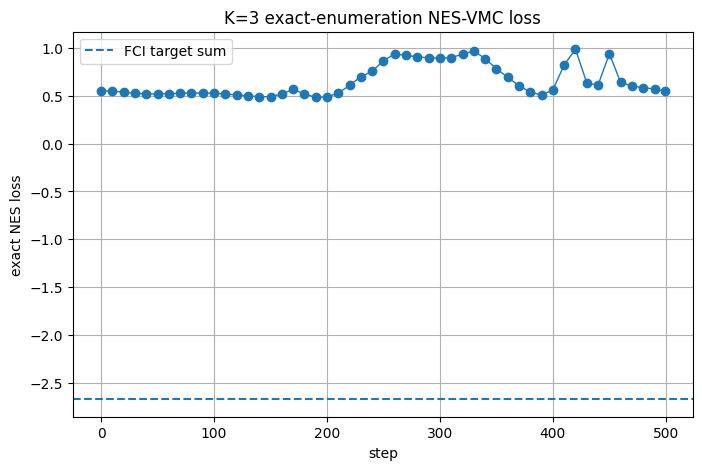

In [10]:
import matplotlib.pyplot as plt

steps = np.asarray(history["step"])
losses = np.asarray([float(x) for x in history["loss"]])

plt.figure(figsize=(8, 5))
plt.plot(steps, losses, marker="o", linewidth=1)
plt.axhline(target_loss, linestyle="--", label="FCI target sum")
plt.xlabel("step")
plt.ylabel("exact NES loss")
plt.title("K=3 exact-enumeration NES-VMC loss")
plt.legend()
plt.grid(True)
plt.show()

## 9. 结果解释模板

跑完以后按下面判断：

### 情况 A：枚举版稳定，MCMC 版不稳定
主锅是 sampler / proposal / 采样塌缩。下一步回到 MCMC，加 global replacement、row swap、rollback、sampler reset。

### 情况 B：枚举版也炸
主锅不是 sampler，而是 K=3 NES 本体：column collapse、determinant conditioning、E_L matrix solve、optimizer、ansatz 表达和状态分离。

### 情况 C：exact span Ritz 很好，但 NES loss 不好
single ansatz 子空间其实学到了，但 NES determinant / local-energy matrix / 权重公式可能有问题。

### 情况 D：exact span Ritz 也不好
K 个 single ansatz 没有学出低能三维子空间。下一步考虑 FCI/CISD pretraining 或 overlap/orthogonality penalty。